# Reproducing Lorenz Results from Gilpin (NeurIPS 2020)

This notebook reproduces the Lorenz attractor reconstruction results from:

> Gilpin, W. "Deep reconstruction of strange attractors from time series." NeurIPS 2020.
> https://arxiv.org/abs/2002.05909

## Paper parameters (Appendix, Section 3)

- **Lorenz ODE**: $\sigma=10$, $\rho=28$, $\beta=2.667$
- **Integration**: LSODA method, $\Delta t = 0.004$
- **Trajectory length**: 125,000 steps (total time = 500)
- **Transient removal**: discard first 120,000 steps, keep last 5,000 per trajectory
- **Downsampling**: factor of 10
- **Observable**: $x(t)$ only (first coordinate, univariate)
- **Train/val/test**: 5,000 timepoints each, from 3 trajectories with different ICs

## Model parameters (Appendix, Section 5)

- **LSTM autoencoder**: `[Input-GN-LSTM(10)-BN]-[GN-LSTM(10)-BN-ELU-Output]`
- **MLP autoencoder**: `[Input-GN-FC(10)-BN-ELU-FC(10)-BN-ELU-FC(10)-BN]-[GN-FC(10)-BN-ELU-FC(10)-BN-ELU-FC(10)-BN-ELU-Output]`
- **Latent units**: $L=10$
- **GaussianNoise**: stddev = 0.5 (training only)
- **FNN regularizer**: $R_{tol}=10$, $A_{tol}=2.0$, $K=\max(1, \lceil 0.01B \rceil)$
- **Optimizer**: Adam, $\gamma = 10^{-3}$ (default)
- **Batch size**: 100
- **Training epochs**: 200
- **5 replicate** networks with random initializations per $\lambda$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.spatial import procrustes
from sklearn.decomposition import PCA

from JacobianODE.fnn import (
    LSTMEmbedding,
    MLPEmbedding,
    ETDEmbedding,
    TICAEmbedding,
    FNN,
    compute_variances,
    compute_s_dim,
)

## 1. Generate Lorenz data (exact paper parameters)

In [3]:
# Lorenz system parameters (Appendix Eq. A1-A3)
SIGMA = 10.0
RHO = 28.0
BETA = 2.667  # paper uses 2.667, not 8/3

# Integration parameters (Appendix Section 3)
DT = 0.004           # integration stepsize
N_STEPS = 125_000     # total steps per trajectory (total time = 500)
DOWNSAMPLE = 10       # downsampling factor
N_KEEP = 5000         # points to keep per partition (last 5000 after downsampling)


def lorenz(t, y, sigma=SIGMA, rho=RHO, beta=BETA):
    """Lorenz system RHS."""
    x, y_, z = y
    return [
        sigma * (y_ - x),
        x * (rho - z) - y_,
        x * y_ - beta * z,
    ]


def simulate_lorenz(ic, n_steps=N_STEPS, dt=DT):
    """Integrate the Lorenz system using LSODA (as in the paper)."""
    t_span = (0, n_steps * dt)
    t_eval = np.arange(0, n_steps * dt, dt)
    sol = solve_ivp(
        lorenz, t_span, ic, method="LSODA",
        t_eval=t_eval, rtol=1e-8, atol=1e-8,
    )
    return sol.y.T  # (n_steps, 3)


# Three different initial conditions for train/val/test
ics = [
    [1.0, 1.0, 1.0],
    [-5.0, 3.0, 20.0],
    [10.0, -10.0, 25.0],
]

trajectories = []
for ic in ics:
    traj = simulate_lorenz(ic)
    # Downsample by factor of 10
    traj_ds = traj[::DOWNSAMPLE]
    # Keep last 5000 points (discard transients)
    traj_ds = traj_ds[-N_KEEP:]
    trajectories.append(traj_ds)
    print(f"IC={ic} -> raw shape {traj.shape}, downsampled+trimmed shape {traj_ds.shape}")

train_full = trajectories[0]  # (5000, 3)
val_full = trajectories[1]
test_full = trajectories[2]

# Paper uses only x(t) as the observable
train_x = train_full[:, 0]  # (5000,)
val_x = val_full[:, 0]
test_x = test_full[:, 0]

print(f"\nTrain/Val/Test univariate shapes: {train_x.shape}, {val_x.shape}, {test_x.shape}")
print(f"Effective dt after downsampling: {DT * DOWNSAMPLE}")

IC=[1.0, 1.0, 1.0] -> raw shape (125000, 3), downsampled+trimmed shape (5000, 3)
IC=[-5.0, 3.0, 20.0] -> raw shape (125000, 3), downsampled+trimmed shape (5000, 3)
IC=[10.0, -10.0, 25.0] -> raw shape (125000, 3), downsampled+trimmed shape (5000, 3)

Train/Val/Test univariate shapes: (5000,), (5000,), (5000,)
Effective dt after downsampling: 0.04


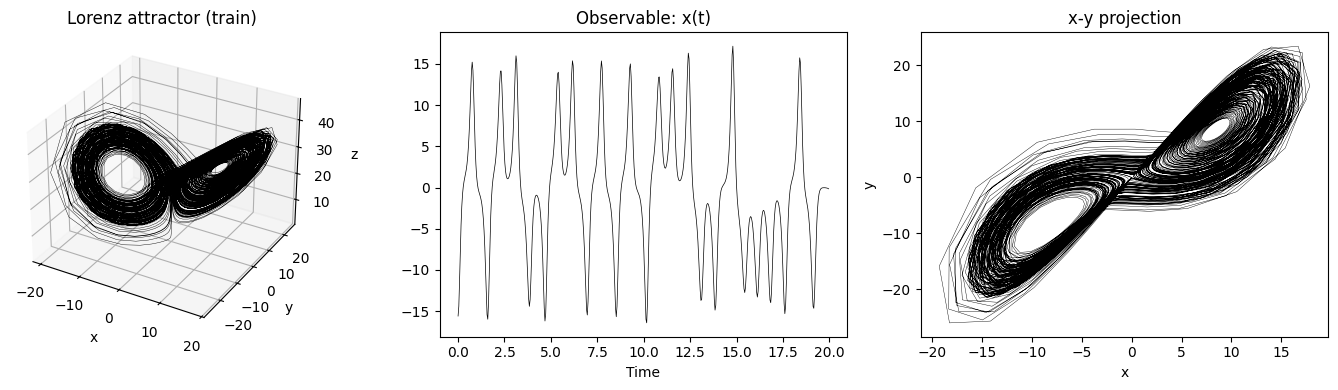

In [4]:
# Visualize the Lorenz attractor and the univariate observable
fig = plt.figure(figsize=(14, 4))

ax1 = fig.add_subplot(131, projection="3d")
ax1.plot(*train_full.T, lw=0.3, c="k")
ax1.set_title("Lorenz attractor (train)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

ax2 = fig.add_subplot(132)
t = np.arange(len(train_x)) * DT * DOWNSAMPLE
ax2.plot(t[:500], train_x[:500], lw=0.5, c="k")
ax2.set_title("Observable: x(t)")
ax2.set_xlabel("Time")

ax3 = fig.add_subplot(133)
ax3.plot(train_full[:, 0], train_full[:, 1], lw=0.3, c="k")
ax3.set_title("x-y projection")
ax3.set_xlabel("x"); ax3.set_ylabel("y")

plt.tight_layout()
plt.show()

## 2. Model setup (exact paper architecture)

From Appendix Section 5:
- LSTM: `[Input-GN-LSTM(10)-BN]-[GN-LSTM(10)-BN-ELU-Output]` — single-layer LSTM with 10 hidden units
- MLP: 3 FC(10) layers in both encoder and decoder
- Both use L=10 latent units
- Time window `T`: the paper uses the Hankel matrix width as a hyperparameter. The paper states T should be "large enough" for sufficient variation. From the original code demos, T=10 is the default.

In [5]:
# Paper architecture parameters
N_LATENT = 10       # L = 10 latent units
TIME_WINDOW = 10    # Hankel matrix width (default in original code)

# Paper training parameters
LEARNING_RATE = 1e-3  # Adam learning rate
BATCH_SIZE = 100      # batch size
TRAIN_STEPS = 200     # training epochs
N_REPLICATES = 1      # 5 replicate networks per setting

## 3. Sweep regularizer strength $\lambda$ (Figure 5)

The paper shows that increasing $\lambda$ causes the distribution of latent activations to develop increasing right skewness, with optimal $S_{\text{dim}}$ at intermediate $\lambda$.

In [6]:
def pad_variances(data_3d, n_latent):
    """Compute normalized variances of the true system, padded to n_latent dims."""
    d = data_3d.shape[1]
    if d < n_latent:
        padding = np.zeros((data_3d.shape[0], n_latent - d))
        data_padded = np.concatenate([data_3d, padding], axis=1)
    else:
        data_padded = data_3d[:, :n_latent]
    return compute_variances(data_padded, normalize=True)

In [7]:
# True system normalized variances (for S_dim computation)
var_true = pad_variances(test_full, N_LATENT)
print(f"True system normalized variances: {var_true}")
print(f"True system has {np.sum(var_true > 0.01)} active dimensions")

True system normalized variances: [1.         0.54619741 0.06237124 0.         0.         0.
 0.         0.         0.         0.        ]
True system has 3 active dimensions


In [ ]:
# Lambda sweep for LSTM model (paper Figure 5)
lambda_values = [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

lstm_results = {
    "lambda": [],
    "s_dim_mean": [],
    "s_dim_std": [],
    "norm_vars": [],      # all replicate variance vectors
    "best_var": [],   # best replicate per lambda
}

for lam in lambda_values:
    print(f"\n=== Lambda = {lam} ===")
    replicate_s_dims = []
    replicate_vars = []
    
    for rep in range(N_REPLICATES):
        reg = FNN(lam) if lam > 0 else None
        # Paper LSTM: single LSTM layer with 10 hidden units -> network_shape=[]
        # (final LSTM has n_latent=10 units, matching the paper's LSTM(10))
        model = LSTMEmbedding(
            n_latent=N_LATENT,
            time_window=TIME_WINDOW,
            n_features=1,
            network_shape=[],  # single-layer LSTM as in paper
            latent_regularizer=reg,
        )
        model.fit(
            train_x,
            learning_rate=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            train_steps=TRAIN_STEPS,
            verbose=0,
        )
        
        # Evaluate on test data
        embedding = model.transform(test_x)  # (n_windows, N_LATENT)
        pred_var = compute_variances(embedding, normalize=True)
        s_dim = compute_s_dim(var_true, pred_var)
        
        replicate_s_dims.append(s_dim)
        replicate_vars.append(pred_var)
        print(f"  Replicate {rep+1}/{N_REPLICATES}: S_dim={s_dim:.4f}")
    
    s_dims = np.array(replicate_s_dims)
    best_idx = np.argmax(s_dims)
    
    lstm_results["lambda"].append(lam)
    lstm_results["s_dim_mean"].append(s_dims.mean())
    lstm_results["s_dim_std"].append(s_dims.std())
    lstm_results["norm_vars"].append(replicate_vars)
    lstm_results["best_var"].append(replicate_vars[best_idx])
    
    print(f"  Mean S_dim = {s_dims.mean():.4f} +/- {s_dims.std():.4f}")

## 4. Reproduce Figure 5: Latent variance distributions & dimensionality error

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel A: Normalized latent variances per lambda ---
colors = plt.cm.coolwarm(np.linspace(0, 1, len(lambda_values)))
for i, (lam, nvars) in enumerate(zip(lstm_results["lambda"], lstm_results["norm_vars"])):
    # Plot mean across replicates
    mean_nv = np.mean(nvars, axis=0)
    std_nv = np.std(nvars, axis=0)
    x = np.arange(1, N_LATENT + 1)
    ax1.plot(x, mean_nv, "o-", color=colors[i], label=f"$\\lambda={lam}$", markersize=4)
    ax1.fill_between(x, mean_nv - std_nv, mean_nv + std_nv, alpha=0.1, color=colors[i])

# Overlay true system variances
ax1.plot(x, var_true, "k-", lw=2, label="True system")
# Overlay best performing model (dashed)
best_overall_idx = np.argmax(lstm_results["s_dim_mean"])
ax1.plot(x, lstm_results["best_var"][best_overall_idx], "k--", lw=2, label="Best LSTM")

ax1.set_xlabel("Latent index")
ax1.set_ylabel("Normalized variance")
ax1.set_title("(A) Latent variance distribution")
ax1.legend(fontsize=7, loc="upper right")
# ax1.set_yscale("log")
ax1.set_ylim(bottom=1e-4)

# --- Panel B: Dimensionality error (1 - S_dim) vs lambda ---
lam_plot = [max(l, 1e-6) for l in lstm_results["lambda"]]  # avoid log(0)
dim_errors = [1.0 - s for s in lstm_results["s_dim_mean"]]
dim_err_std = lstm_results["s_dim_std"]

ax2.errorbar(lam_plot, dim_errors, yerr=dim_err_std, fmt="o-", color="tab:blue", capsize=3)
ax2.set_xscale("log")
ax2.set_xlabel(r"Regularizer strength $\lambda$")
ax2.set_ylabel(r"Dimensionality error $(1 - S_{\mathrm{dim}})$")
ax2.set_title(r"(B) Dimensionality error vs $\lambda$")

plt.tight_layout()
plt.show()

## 5. Baseline comparisons (Figure 3B)

Compare LSTM+FNN against ETD, tICA, and unregularized LSTM.

In [11]:
# Best lambda from sweep (use the one with highest mean S_dim)
best_lambda = lstm_results["lambda"][best_overall_idx]
print(f"Best lambda from sweep: {best_lambda}")

baseline_results = {}

# --- ETD (Eigen-Time-Delay / PCA of Hankel matrix) ---
print("\nTraining ETD...")
etd = ETDEmbedding(n_latent=N_LATENT, time_window=TIME_WINDOW)
etd.fit(train_x)
etd_emb = etd.transform(test_x)
nv_etd = compute_variances(etd_emb, normalize=True)
s_dim_etd = compute_s_dim(var_true, nv_etd)
baseline_results["ETD"] = {"embedding": etd_emb, "s_dim": s_dim_etd, "norm_var": nv_etd}
print(f"  ETD S_dim = {s_dim_etd:.4f}")

# --- tICA ---
print("\nTraining tICA...")
tica = TICAEmbedding(n_latent=N_LATENT, time_window=TIME_WINDOW, time_lag=1)
tica.fit(train_x)
tica_emb = tica.transform(test_x)
nv_tica = compute_variances(tica_emb, normalize=True)
s_dim_tica = compute_s_dim(var_true, nv_tica)
baseline_results["tICA"] = {"embedding": tica_emb, "s_dim": s_dim_tica, "norm_var": nv_tica}
print(f"  tICA S_dim = {s_dim_tica:.4f}")

# --- Unregularized LSTM (lambda=0) ---
print("\nTraining LSTM (no regularizer)...")
unreg_s_dims = []
unreg_embs = []
for rep in range(N_REPLICATES):
    model_unreg = LSTMEmbedding(
        n_latent=N_LATENT, time_window=TIME_WINDOW, network_shape=[],
    )
    model_unreg.fit(train_x, learning_rate=LEARNING_RATE, batch_size=BATCH_SIZE,
                    train_steps=TRAIN_STEPS, verbose=0)
    emb = model_unreg.transform(test_x)
    nv = compute_variances(emb, normalize=True)
    s = compute_s_dim(var_true, nv)
    unreg_s_dims.append(s)
    unreg_embs.append(emb)

best_unreg = np.argmax(unreg_s_dims)
baseline_results["LSTM"] = {
    "embedding": unreg_embs[best_unreg],
    "s_dim": np.mean(unreg_s_dims),
    "s_dim_std": np.std(unreg_s_dims),
    "norm_var": compute_variances(unreg_embs[best_unreg], normalize=True),
}
print(f"  LSTM S_dim = {np.mean(unreg_s_dims):.4f} +/- {np.std(unreg_s_dims):.4f}")

# --- LSTM + FNN (best lambda) ---
print(f"\nTraining LSTM + FNN (lambda={best_lambda})...")
fnn_s_dims = []
fnn_embs = []
for rep in range(N_REPLICATES):
    model_fnn = LSTMEmbedding(
        n_latent=N_LATENT, time_window=TIME_WINDOW, network_shape=[],
        latent_regularizer=FNN(best_lambda),
    )
    model_fnn.fit(train_x, learning_rate=LEARNING_RATE, batch_size=BATCH_SIZE,
                  train_steps=TRAIN_STEPS, verbose=0)
    emb = model_fnn.transform(test_x)
    nv = compute_variances(emb, normalize=True)
    s = compute_s_dim(var_true, nv)
    fnn_s_dims.append(s)
    fnn_embs.append(emb)

best_fnn = np.argmax(fnn_s_dims)
baseline_results["LSTM-FNN"] = {
    "embedding": fnn_embs[best_fnn],
    "s_dim": np.mean(fnn_s_dims),
    "s_dim_std": np.std(fnn_s_dims),
    "norm_var": compute_variances(fnn_embs[best_fnn], normalize=True),
}
print(f"  LSTM-FNN S_dim = {np.mean(fnn_s_dims):.4f} +/- {np.std(fnn_s_dims):.4f}")

Best lambda from sweep: 0.001

Training ETD...
  ETD S_dim = 0.7259

Training tICA...
  tICA S_dim = -0.5987

Training LSTM (no regularizer)...
  LSTM S_dim = 0.2931 +/- 0.0000

Training LSTM + FNN (lambda=0.001)...
  LSTM-FNN S_dim = 0.7972 +/- 0.0000


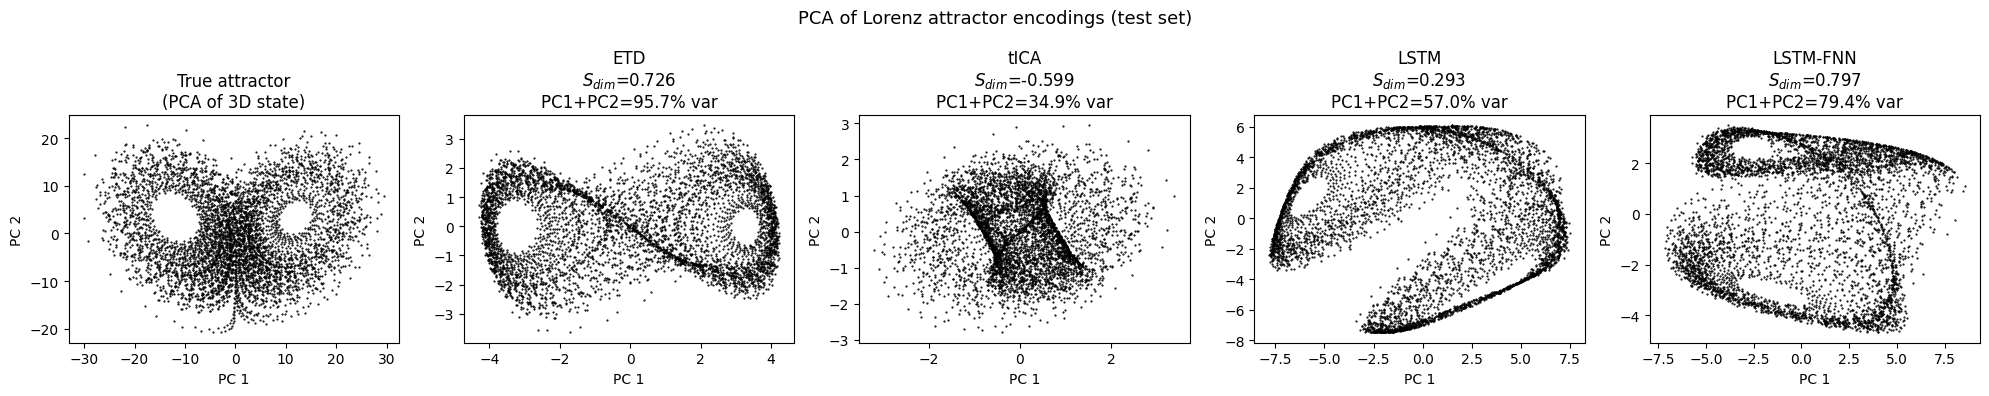

In [12]:
# PCA of Lorenz attractor encodings for each baseline model
fig, axes = plt.subplots(1, len(baseline_results) + 1, figsize=(4 * (len(baseline_results) + 1), 4))

# True attractor (PCA of full 3D state for reference)
pca_true = PCA(n_components=2)
true_2d = pca_true.fit_transform(test_full)
axes[0].scatter(true_2d[:, 0], true_2d[:, 1], s=0.3, c="k", rasterized=True)
axes[0].set_title("True attractor\n(PCA of 3D state)")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

for i, (name, res) in enumerate(baseline_results.items()):
    emb = res["embedding"]
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb)
    var_explained = pca.explained_variance_ratio_

    axes[i + 1].scatter(emb_2d[:, 0], emb_2d[:, 1], s=0.3, c="k", rasterized=True)
    axes[i + 1].set_title(
        f"{name}\n$S_{{dim}}$={res['s_dim']:.3f}\n"
        f"PC1+PC2={100*(var_explained[0]+var_explained[1]):.1f}% var"
    )
    axes[i + 1].set_xlabel("PC 1")
    axes[i + 1].set_ylabel("PC 2")

plt.suptitle("PCA of Lorenz attractor encodings (test set)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Reproduce Figure 3A: Visualize reconstructed attractors

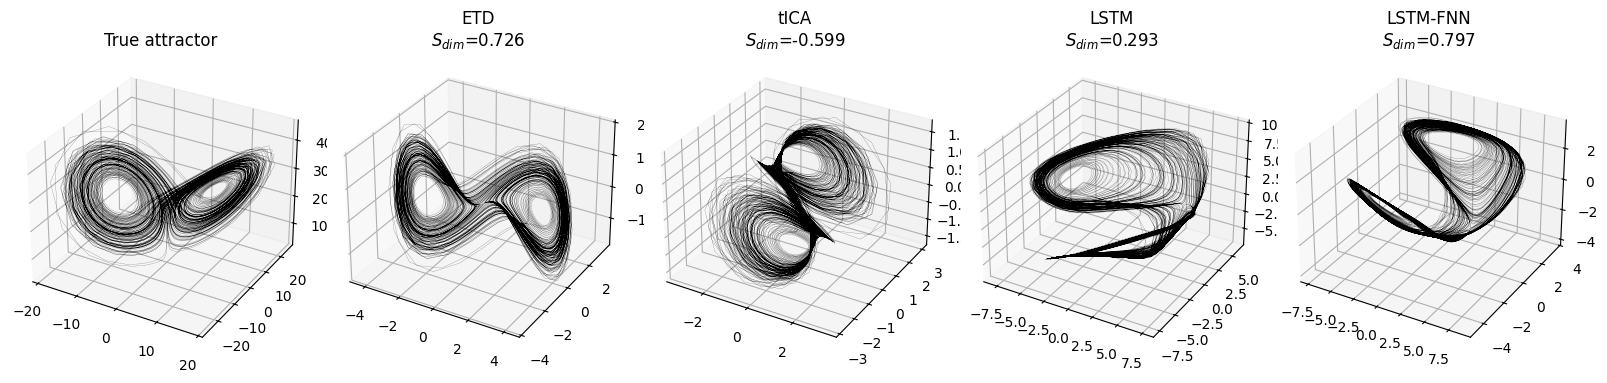

In [13]:
fig = plt.figure(figsize=(16, 4))

# True attractor (first 3 coords)
ax = fig.add_subplot(151, projection="3d")
ax.plot(*test_full.T, lw=0.1, c="k")
ax.set_title("True attractor")

# For each method, PCA to 3D and plot
for i, (name, res) in enumerate(baseline_results.items()):
    emb = res["embedding"]
    # Use PCA to extract top 3 components for visualization
    pca = PCA(n_components=3)
    emb_3d = pca.fit_transform(emb)
    
    ax = fig.add_subplot(1, 5, i + 2, projection="3d")
    ax.plot(*emb_3d.T, lw=0.1, c="k")
    s_dim_val = res["s_dim"]
    ax.set_title(f"{name}\n$S_{{dim}}$={s_dim_val:.3f}")

plt.tight_layout()
plt.show()

## 7. MLP autoencoder comparison (Appendix)

Paper MLP: `[Input-GN-FC(10)-BN-ELU-FC(10)-BN-ELU-FC(10)-BN]-[GN-FC(10)-BN-ELU-FC(10)-BN-ELU-FC(10)-BN-ELU-Output]`

This is a 3-layer MLP with 10 units per layer, matching `network_shape=[10, 10]` (plus the latent layer = 3rd FC).

In [ ]:
# Lambda sweep for MLP model (Appendix Figure S4)
mlp_results = {
    "lambda": [],
    "s_dim_mean": [],
    "s_dim_std": [],
    "norm_vars": [],
    "best_var": [],
}

for lam in lambda_values:
    print(f"\n=== MLP Lambda = {lam} ===")
    replicate_s_dims = []
    replicate_vars = []
    
    for rep in range(N_REPLICATES):
        reg = FNN(lam) if lam > 0 else None
        # Paper MLP: 3 FC layers with 10 units each
        # network_shape=[10, 10] gives 2 hidden + 1 latent = 3 layers in encoder
        model = MLPEmbedding(
            n_latent=N_LATENT,
            time_window=TIME_WINDOW,
            n_features=1,
            network_shape=[10, 10],  # paper architecture
            latent_regularizer=reg,
        )
        model.fit(
            train_x,
            learning_rate=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            train_steps=TRAIN_STEPS,
            verbose=0,
        )
        
        embedding = model.transform(test_x)
        nv = compute_variances(embedding, normalize=True)
        s_dim = compute_s_dim(var_true, nv)
        
        replicate_s_dims.append(s_dim)
        replicate_vars.append(nv)
        print(f"  Replicate {rep+1}/{N_REPLICATES}: S_dim={s_dim:.4f}")
    
    s_dims = np.array(replicate_s_dims)
    best_idx = np.argmax(s_dims)
    
    mlp_results["lambda"].append(lam)
    mlp_results["s_dim_mean"].append(s_dims.mean())
    mlp_results["s_dim_std"].append(s_dims.std())
    mlp_results["norm_vars"].append(replicate_vars)
    mlp_results["best_var"].append(replicate_vars[best_idx])
    
    print(f"  Mean S_dim = {s_dims.mean():.4f} +/- {s_dims.std():.4f}")

In [ ]:
# Combined Figure 5 / S4: LSTM and MLP comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, (name, results) in enumerate([("LSTM", lstm_results), ("MLP", mlp_results)]):
    ax_var, ax_err = axes[row]
    
    # Panel A: Normalized latent variances
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(lambda_values)))
    for i, (lam, nvars) in enumerate(zip(results["lambda"], results["norm_vars"])):
        mean_nv = np.mean(nvars, axis=0)
        x = np.arange(1, N_LATENT + 1)
        ax_var.plot(x, mean_nv, "o-", color=colors[i], label=f"$\\lambda={lam}$", markersize=3)
    ax_var.plot(x, var_true, "k-", lw=2, label="True system")
    ax_var.set_xlabel("Latent index")
    ax_var.set_ylabel("Normalized variance")
    ax_var.set_title(f"{name}: Latent variance distribution")
    ax_var.legend(fontsize=7)
    ax_var.set_yscale("log")
    ax_var.set_ylim(bottom=1e-4)
    
    # Panel B: Dimensionality error
    lam_plot = [max(l, 1e-6) for l in results["lambda"]]
    dim_errors = [1.0 - s for s in results["s_dim_mean"]]
    ax_err.errorbar(lam_plot, dim_errors, yerr=results["s_dim_std"], fmt="o-", capsize=3)
    ax_err.set_xscale("log")
    ax_err.set_xlabel(r"Regularizer strength $\lambda$")
    ax_err.set_ylabel(r"Dimensionality error $(1 - S_{\mathrm{dim}})$")
    ax_err.set_title(f"{name}: Dimensionality error vs $\\lambda$")

plt.tight_layout()
plt.show()

## 8. Consistency across replicates (Figure S3, Appendix B)

Train an ensemble of LSTM models with and without FNN to show that the regularizer produces more consistent embeddings.

In [ ]:
n_ensemble = 5

# Train replicates without regularizer
print("Training LSTM ensemble (no regularizer)...")
unreg_embeddings = []
for i in range(n_ensemble):
    m = LSTMEmbedding(n_latent=N_LATENT, time_window=TIME_WINDOW, network_shape=[])
    m.fit(train_x, learning_rate=LEARNING_RATE, batch_size=BATCH_SIZE,
          train_steps=TRAIN_STEPS, verbose=0)
    unreg_embeddings.append(m.transform(test_x))
    print(f"  Replicate {i+1}/{n_ensemble} done")

# Train replicates with FNN regularizer
print(f"\nTraining LSTM+FNN ensemble (lambda={best_lambda})...")
fnn_embeddings = []
for i in range(n_ensemble):
    m = LSTMEmbedding(n_latent=N_LATENT, time_window=TIME_WINDOW, network_shape=[],
                      latent_regularizer=FNN(best_lambda))
    m.fit(train_x, learning_rate=LEARNING_RATE, batch_size=BATCH_SIZE,
          train_steps=TRAIN_STEPS, verbose=0)
    fnn_embeddings.append(m.transform(test_x))
    print(f"  Replicate {i+1}/{n_ensemble} done")

In [ ]:
fig, axes = plt.subplots(2, n_ensemble, figsize=(4 * n_ensemble, 8),
                         subplot_kw={"projection": "3d"})

for i in range(n_ensemble):
    # Unreg row
    pca = PCA(n_components=3)
    emb_3d = pca.fit_transform(unreg_embeddings[i])
    axes[0, i].plot(*emb_3d.T, lw=0.1, c="k")
    if i == 0:
        axes[0, i].set_ylabel("LSTM (no reg)")
    axes[0, i].set_title(f"Rep {i+1}")
    
    # FNN row
    pca = PCA(n_components=3)
    emb_3d = pca.fit_transform(fnn_embeddings[i])
    axes[1, i].plot(*emb_3d.T, lw=0.1, c="k")
    if i == 0:
        axes[1, i].set_ylabel("LSTM + FNN")

fig.suptitle("Consistency across replicates (cf. Figure S3)", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Stochastic Lorenz (Figure 4)

From the paper: "an uncorrelated white noise term $\xi(t)$ is appended to each dynamical variable before integration, the integration timestep is decreased to $\Delta t = 0.0004$, and the integration output is downsampled by a factor of 100."

In [ ]:
def simulate_stochastic_lorenz(ic, xi0, n_steps=125_000, dt=0.0004, downsample=100):
    """Euler-Maruyama integration of stochastic Lorenz system.
    
    The paper adds uncorrelated white noise xi(t) to each variable.
    For SDE integration we use Euler-Maruyama since LSODA is for ODEs.
    """
    y = np.array(ic, dtype=float)
    trajectory = np.zeros((n_steps, 3))
    sqrt_dt = np.sqrt(dt)
    
    for i in range(n_steps):
        trajectory[i] = y
        # Deterministic part
        dydt = np.array(lorenz(0, y))
        # Stochastic part: uncorrelated white noise
        noise = xi0 * np.random.randn(3) * sqrt_dt
        y = y + dydt * dt + noise
    
    # Downsample
    return trajectory[::downsample]


# Generate stochastic trajectories at different noise levels
xi0_values = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]

print("Generating stochastic Lorenz trajectories...")
stoch_train = {}
stoch_test = {}
for xi0 in xi0_values:
    # Different ICs for train/test
    np.random.seed(42)
    tr = simulate_stochastic_lorenz([1.0, 1.0, 1.0], xi0)
    np.random.seed(123)
    te = simulate_stochastic_lorenz([-5.0, 3.0, 20.0], xi0)
    stoch_train[xi0] = tr[-N_KEEP:, 0]  # x(t), last 5000 points
    stoch_test[xi0] = te[-N_KEEP:, 0]
    print(f"  xi0={xi0}: train shape {stoch_train[xi0].shape}")

In [ ]:
# Visualize stochastic trajectories
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, xi0 in enumerate(xi0_values):
    ax = axes.flat[i]
    ax.plot(stoch_train[xi0][:500], lw=0.5, c="k")
    ax.set_title(f"$\\xi_0 = {xi0}$")
    ax.set_xlabel("Time index")
plt.suptitle("Stochastic Lorenz x(t) at different noise levels")
plt.tight_layout()
plt.show()

In [ ]:
# Figure 4B: S_dim vs noise strength for LSTM and LSTM+FNN
print("Training models across noise levels...")
stoch_results = {"xi0": [], "lstm_sdim": [], "fnn_sdim": []}

for xi0 in xi0_values:
    print(f"\nxi0 = {xi0}")
    
    # LSTM without FNN
    m_unreg = LSTMEmbedding(n_latent=N_LATENT, time_window=TIME_WINDOW, network_shape=[])
    m_unreg.fit(stoch_train[xi0], learning_rate=LEARNING_RATE,
                batch_size=BATCH_SIZE, train_steps=TRAIN_STEPS, verbose=0)
    emb_unreg = m_unreg.transform(stoch_test[xi0])
    nv_unreg = compute_variances(emb_unreg, normalize=True)
    s_unreg = compute_s_dim(var_true, nv_unreg)
    
    # LSTM with FNN
    m_fnn = LSTMEmbedding(n_latent=N_LATENT, time_window=TIME_WINDOW, network_shape=[],
                          latent_regularizer=FNN(best_lambda))
    m_fnn.fit(stoch_train[xi0], learning_rate=LEARNING_RATE,
              batch_size=BATCH_SIZE, train_steps=TRAIN_STEPS, verbose=0)
    emb_fnn = m_fnn.transform(stoch_test[xi0])
    nv_fnn = compute_variances(emb_fnn, normalize=True)
    s_fnn = compute_s_dim(var_true, nv_fnn)
    
    stoch_results["xi0"].append(xi0)
    stoch_results["lstm_sdim"].append(s_unreg)
    stoch_results["fnn_sdim"].append(s_fnn)
    print(f"  LSTM: S_dim={s_unreg:.4f}, LSTM+FNN: S_dim={s_fnn:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(stoch_results["xi0"], stoch_results["lstm_sdim"], "o-", label="LSTM", color="tab:blue")
ax.plot(stoch_results["xi0"], stoch_results["fnn_sdim"], "s-", label="LSTM + FNN", color="tab:red")
ax.set_xlabel(r"Noise amplitude $\xi_0$")
ax.set_ylabel(r"$S_{\mathrm{dim}}$")
ax.set_title("Dimension similarity vs noise strength (cf. Figure 4B)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary

This notebook reproduces the key Lorenz results from Gilpin (NeurIPS 2020):

1. **Data generation**: Lorenz system with exact paper parameters ($\sigma=10, \rho=28, \beta=2.667$, LSODA integration at $\Delta t=0.004$, downsampled $\times 10$, 5000 points per partition)
2. **Architecture**: Single-layer LSTM and 3-layer MLP, both with 10 hidden units and $L=10$ latent dimensions
3. **Figure 5**: $\lambda$ sweep showing optimal dimensionality recovery at intermediate regularizer strength
4. **Figure 3**: Baseline comparisons (ETD, tICA, LSTM, LSTM+FNN)
5. **Figure S3**: Consistency of embeddings across replicate trainings
6. **Figure 4**: Robustness to stochastic forcing